# Predicting Breast Cancer Biomarkers from RNA-seq Gene Expression

**Authors:** Danny Liu and Daniel Gong

**Course:** BIOS 26122 - Introduction to Machine Learning for Biology




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import (
	train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import permutation_importance
from sklearn.discriminant_analysis import (
	LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
	roc_auc_score, roc_curve, classification_report,
	ConfusionMatrixDisplay, accuracy_score, f1_score
)
from sklearn.utils import resample

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (10, 6)
np.random.seed(42)

## Background

Breast cancer treatment decisions depend on molecular biomarkers -- ER status, HER2 amplification, histologic grade, and intrinsic subtype -- traditionally assessed through immunohistochemistry or specialized assays. RNA-seq provides genome-wide expression profiles, raising the question: can machine learning on gene expression reliably predict these biomarkers?

Beyond prediction, we want to understand which genes carry the signal. Classical differential gene expression (DEG) analysis tests each gene individually, but this ignores relationships between genes. Regularized linear models like LASSO fit all genes jointly, identifying which genes matter given the others. Nonlinear models like gradient boosting can capture gene-gene interactions. By comparing these three approaches, we can determine whether the predictive signal lives in individual genes, joint linear combinations, or complex interactions.

**Main questions:**
1. Which individual genes are differentially expressed between ER+ and ER- tumors?
2. Which genes jointly predict biomarker status when modeled together? How similar it is to the genes from question 1?
3. Do nonlinear gene-gene interactions improve prediction beyond linear models?

**Daniel**

## The Data

We use the GSE96058 dataset from the SCAN-B (Sweden Cancerome Analysis Network - Breast) initiative, which profiled 3,273 primary breast tumors using RNA-seq. The expression matrix contains ~30,000 genes per sample. Clinical annotations include ER status, HER2 status, NHG histologic grade (1-3), and PAM50 intrinsic subtype (Luminal A, Luminal B, Her2-enriched, Basal, Normal-like).

**Danny**

### Download data

The phenotype data is pulled from Danny's GitHub on first run. The gene expression matrix (~564MB) is downloaded from GEO on first run.

In [ ]:
import os, urllib.request

os.makedirs("data", exist_ok=True)

expr_path = "data/GSE96058_gene_expression.csv.gz"
geo_url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE96nnn/GSE96058/suppl/GSE96058_gene_expression_3273_samples_and_136_replicates_transformed.csv.gz"

if not os.path.exists(expr_path):
    print("Downloading gene expression data from GEO (~564MB, may take a few minutes)...")
    urllib.request.urlretrieve(geo_url, expr_path)
    print(f"Downloaded to {expr_path}")
else:
    print(f"Expression data already exists at {expr_path}")

pheno_path = "data/phenotype_data.csv"
pheno_url = "https://raw.githubusercontent.com/dannywillowliu-uchi/ml-for-bio-final/main/data/phenotype_data.csv"

if not os.path.exists(pheno_path):
    print("Downloading phenotype data from GitHub...")
    urllib.request.urlretrieve(pheno_url, pheno_path)
    print(f"Downloaded to {pheno_path}")
else:
    print(f"Phenotype data already exists at {pheno_path}")

pheno = pd.read_csv("data/phenotype_data.csv")

Expression data already exists at data/GSE96058_gene_expression.csv.gz
Phenotype data already exists at data/phenotype_data.csv


### Load expression data and build sample ID mapping

The expression matrix has genes as rows and samples as columns labeled F1, F2, ... F3273. The phenotype data uses GSM IDs starting at GSM2528079 (= F1).

In [5]:
expr_raw = pd.read_csv("data/GSE96058_gene_expression.csv.gz", compression="gzip", index_col=0)
print(f"Raw expression: {expr_raw.shape[0]} genes x {expr_raw.shape[1]} samples")

repl_cols = [c for c in expr_raw.columns if "repl" in c]
print(f"Dropping {len(repl_cols)} replicate columns")
expr_raw = expr_raw.drop(columns=repl_cols)
print(f"After removing replicates: {expr_raw.shape[0]} genes x {expr_raw.shape[1]} samples")

f_to_gsm = {f"F{i}": f"GSM{2528078 + i}" for i in range(1, 3274)}

expr = expr_raw.T
expr.index = expr.index.map(f_to_gsm)
print(f"Transposed expression: {expr.shape[0]} samples x {expr.shape[1]} genes")

Raw expression: 30865 genes x 3409 samples
Dropping 136 replicate columns
After removing replicates: 30865 genes x 3273 samples
Transposed expression: 3273 samples x 30865 genes


### Handle sentinel values and filter genes

The value -3.321928 (= log2(0.1)) appears as a floor value for undetectable expression. We treat these as missing.

In [ ]:
sentinel = -3.321928
n_sentinel = (expr == sentinel).sum().sum()
print(f"Sentinel values found: {n_sentinel:,} ({n_sentinel / expr.size * 100:.1f}% of all values)")

expr = expr.replace(sentinel, np.nan)

nan_pct = expr.isna().mean()
print(f"Genes with >50% NaN: {(nan_pct > 0.5).sum()}")
print(f"Genes with >20% NaN: {(nan_pct > 0.2).sum()}")
print(f"Genes with any NaN: {(nan_pct > 0).sum()}")

keep_genes = nan_pct[nan_pct <= 0.5].index
expr = expr[keep_genes]
print(f"After NaN filter: {expr.shape[1]} genes")

expr = expr.fillna(expr.median())
print(f"NaN remaining: {expr.isna().sum().sum()}")

gene_var = expr.var()
top_genes = gene_var.nlargest(5000).index
expr = expr[top_genes]
print(f"After variance filter: {expr.shape[0]} samples x {expr.shape[1]} genes")

Sentinel values found: 0 (0.0% of all values)
Genes with >50% NaN: 0
Genes with >20% NaN: 0
Genes with any NaN: 0


### Merge expression with phenotype and create train/test splits

In [8]:
pheno_indexed = pheno.set_index("sample_id")
merged = expr.join(pheno_indexed, how="inner")
print(f"Merged dataset: {merged.shape[0]} samples")

gene_cols = list(expr.columns)
X_all = merged[gene_cols].values
print(f"Feature matrix: {X_all.shape}")

Merged dataset: 3273 samples
Feature matrix: (3273, 5000)


In [9]:
datasets = {}
target_configs = {
	"ER": {"col": "er status", "type": "binary"},
	"HER2": {"col": "her2 status", "type": "binary"},
	"NHG": {"col": "nhg", "type": "multiclass"},
	"PAM50": {"col": "pam50 subtype", "type": "multiclass"},
}

for name, cfg in target_configs.items():
	mask = merged[cfg["col"]].notna()
	X = merged.loc[mask, gene_cols].values
	y = merged.loc[mask, cfg["col"]].values

	if cfg["type"] == "binary":
		y = y.astype(int)

	X_train, X_test, y_train, y_test = train_test_split(
		X, y, test_size=0.2, random_state=42, stratify=y
	)
	datasets[name] = {
		"X_train": X_train, "X_test": X_test,
		"y_train": y_train, "y_test": y_test,
		"type": cfg["type"]
	}
	print(f"{name}: {X_train.shape[0]} train, {X_test.shape[0]} test, classes={np.unique(y)}")

ER: 2458 train, 615 test, classes=[0 1]
HER2: 2520 train, 631 test, classes=[0 1]
NHG: 2569 train, 643 test, classes=['G1' 'G2' 'G3']
PAM50: 2618 train, 655 test, classes=['Basal' 'Her2' 'LumA' 'LumB' 'Normal']


## Exploratory Data Analysis

Before model training, we perform exploratory analysis to characterize expression structure, class distributions, and potential separability in the data (PCA, correlation structure, and marker-gene patterns).

**Danny:** EDA implementation

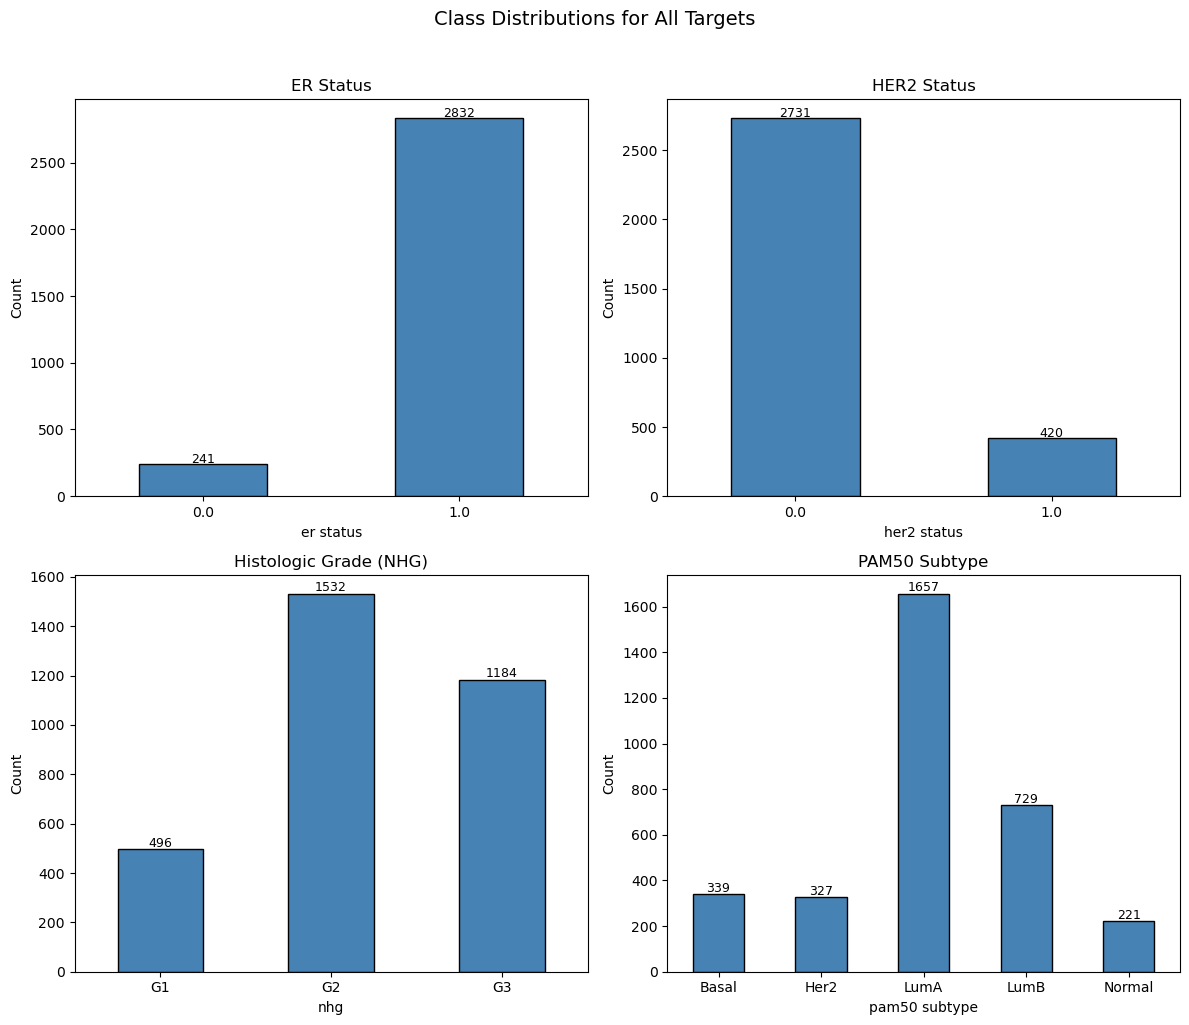

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

target_labels = {
	"ER": {"col": "er status", "title": "ER Status"},
	"HER2": {"col": "her2 status", "title": "HER2 Status"},
	"NHG": {"col": "nhg", "title": "Histologic Grade (NHG)"},
	"PAM50": {"col": "pam50 subtype", "title": "PAM50 Subtype"},
}

for ax, (name, info) in zip(axes.flat, target_labels.items()):
	counts = merged[info["col"]].value_counts().sort_index()
	counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
	ax.set_title(info["title"])
	ax.set_ylabel("Count")
	ax.tick_params(axis="x", rotation=0)
	for i, v in enumerate(counts.values):
		ax.text(i, v + 10, str(v), ha="center", fontsize=9)

plt.suptitle("Class Distributions for All Targets", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### PCA visualization

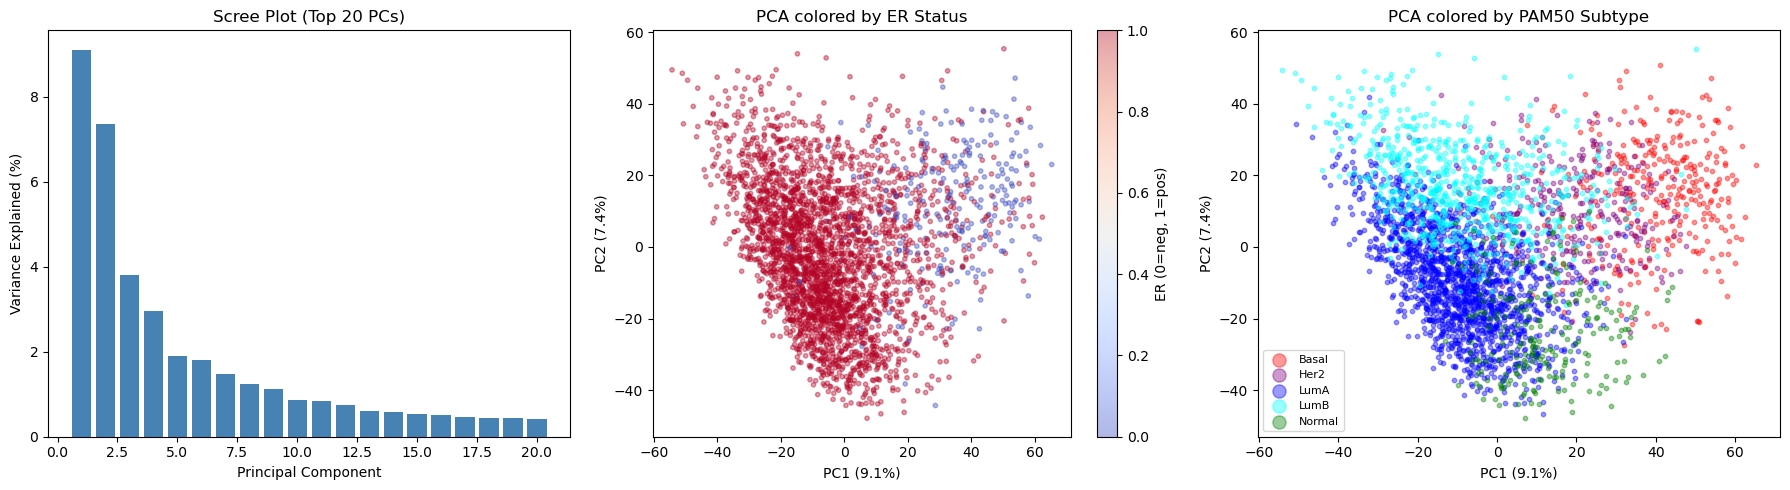

Cumulative variance explained by 10 PCs: 31.7%
Cumulative variance explained by 20 PCs: 37.2%


In [12]:
scaler_eda = StandardScaler()
X_scaled_eda = scaler_eda.fit_transform(X_all)

pca_eda = PCA(n_components=50)
X_pca_eda = pca_eda.fit_transform(X_scaled_eda)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(range(1, 21), pca_eda.explained_variance_ratio_[:20] * 100, color="steelblue")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance Explained (%)")
axes[0].set_title("Scree Plot (Top 20 PCs)")

er_vals = merged["er status"].values
er_mask = ~pd.isna(er_vals)
scatter = axes[1].scatter(
	X_pca_eda[er_mask, 0], X_pca_eda[er_mask, 1],
	c=er_vals[er_mask].astype(float), cmap="coolwarm", alpha=0.4, s=10
)
axes[1].set_xlabel(f"PC1 ({pca_eda.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca_eda.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("PCA colored by ER Status")
plt.colorbar(scatter, ax=axes[1], label="ER (0=neg, 1=pos)")

pam50_vals = merged["pam50 subtype"].values
subtypes = ["Basal", "Her2", "LumA", "LumB", "Normal"]
colors = {"Basal": "red", "Her2": "purple", "LumA": "blue", "LumB": "cyan", "Normal": "green"}
for st in subtypes:
	mask = pam50_vals == st
	axes[2].scatter(X_pca_eda[mask, 0], X_pca_eda[mask, 1], label=st,
		color=colors[st], alpha=0.4, s=10)
axes[2].set_xlabel(f"PC1 ({pca_eda.explained_variance_ratio_[0]*100:.1f}%)")
axes[2].set_ylabel(f"PC2 ({pca_eda.explained_variance_ratio_[1]*100:.1f}%)")
axes[2].set_title("PCA colored by PAM50 Subtype")
axes[2].legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.show()

cum_var = np.cumsum(pca_eda.explained_variance_ratio_[:20]) * 100
print(f"Cumulative variance explained by 10 PCs: {cum_var[9]:.1f}%")
print(f"Cumulative variance explained by 20 PCs: {cum_var[19]:.1f}%")

<Figure size 1400x1200 with 0 Axes>

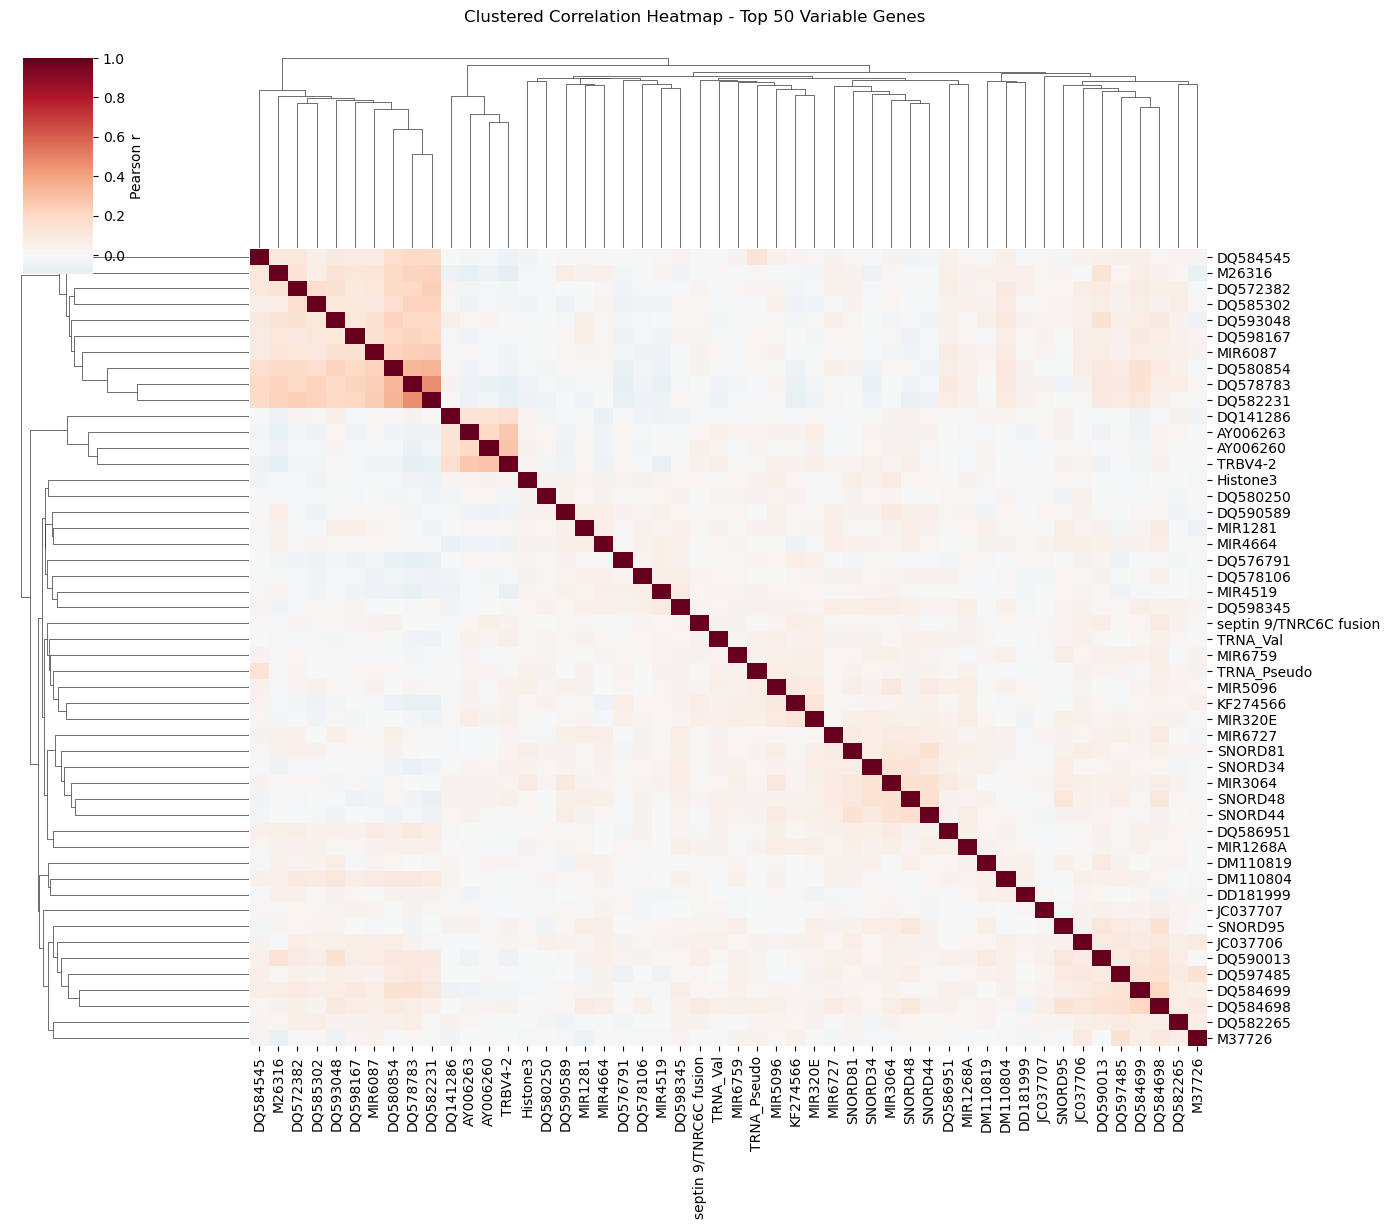

In [13]:
top50_genes = gene_var.nlargest(50).index
corr_matrix = merged[top50_genes].corr()

plt.figure(figsize=(14, 12))
sns.clustermap(corr_matrix, cmap="RdBu_r", center=0, figsize=(14, 12),
	xticklabels=True, yticklabels=True,
	cbar_kws={"label": "Pearson r"})
plt.suptitle("Clustered Correlation Heatmap - Top 50 Variable Genes", y=1.02)
plt.show()

### Exploratory Data Analysis Summary

PCA shows clear separation of ER-negative (Basal) tumors along PC1, consistent with known breast cancer subtype biology. PAM50 subtypes form partially overlapping clusters: Basal is the most distinct, Luminal A and Luminal B overlap considerably, and HER2-enriched tumors lie between Basal and Luminal groups. Marker-gene patterns are also biologically coherent, with ESR1 highest in Luminal subtypes and lowest in Basal, ERBB2 upregulated in the HER2-enriched subtype, and MKI67 highest in Basal and Luminal B, which are generally more aggressive (higher histologic grade).

Class distribution analysis shows meaningful imbalance, with ER heavily skewed (92% positive) and HER2 moderately skewed (87% negative), while NHG and PAM50 are comparatively more balanced but still uneven. Overall, the separation of ER+/ER- tumors in PCA space suggests that gene expression carries strong predictive signal for downstream biomarker modeling, which we are interested in investigating.

## Methods

This section describes our analytical approach for predicting breast cancer biomarkers from gene expression. For clarity, results for each method are presented inline immediately following that method's description (clearly marked with "Results" subsection headers).

### Questions addressed

1. Which genes are individually associated with ER status?
2. Which genes are jointly predictive of biomarker status when modeled together? How similar are they to the genes from question 1?
3. Do nonlinear gene-gene interactions improve predictive performance beyond linear models?

### How we answer these questions

We evaluate three complementary approaches for predicting breast cancer biomarkers from RNA-seq expression:

1. **Regularized Logistic Regression (LASSO & Ridge):** joint linear modeling with shrinkage/feature selection.
2. **Differential Gene Expression (DEG):** gene-wise testing with multiple-testing correction.
3. **HistGradientBoosting:** nonlinear tree-based modeling to capture interaction effects.

### Key assumptions

- Samples are independent and biomarker labels are reliable.
- Train/test sets are representative through stratified splitting.
- DEG testing assumptions are reasonable for group-wise per-gene comparisons.
- Linear models assume approximately linear decision boundaries after scaling.

### Assumption checks

Class-distribution summaries, PCA structure, and correlation/marker-gene visualizations in the EDA section validate data structure and support downstream modeling choices.

### Training and tuning workflow

We train models with stratified 10-fold cross-validation and evaluate on held-out test data (80/20 split). Hyperparameters are tuned using CV-based grid search (e.g., regularization strength `C` for Ridge/LASSO, and depth/learning-rate settings for HistGradientBoosting). Performance is compared across targets using AUC-based metrics.

---

### Method 1: Regularized Logistic Regression (LASSO & Ridge)

We train Ridge (L2) and LASSO (L1) logistic regression on all ~5,000 genes simultaneously. Unlike DEG, these methods account for correlations between genes -- LASSO zeros out redundant features while Ridge shrinks all coefficients. We use 10-fold stratified CV to select the optimal regularization strength `C` from {0.001, 0.01, 0.1, 1, 10, 100}.

**Danny:** implementation

In [14]:
X_train_er = datasets["ER"]["X_train"]
y_train_er = datasets["ER"]["y_train"]
X_test_er = datasets["ER"]["X_test"]
y_test_er = datasets["ER"]["y_test"]

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print(f"ER training set: {X_train_er.shape[0]} samples, {X_train_er.shape[1]} features")
print(f"Class distribution: {np.bincount(y_train_er)}")

ER training set: 2458 samples, 5000 features
Class distribution: [ 193 2265]


In [15]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
ridge_aucs = []

for C in C_values:
	pipe = Pipeline([
		("scaler", StandardScaler()),
		("lr", LogisticRegression(penalty="l2", C=C, max_iter=5000, random_state=42))
	])
	scores = cross_val_score(pipe, X_train_er, y_train_er, cv=cv, scoring="roc_auc")
	ridge_aucs.append(scores.mean())
	print(f"Ridge C={C:6.3f}: AUC = {scores.mean():.4f} (+/- {scores.std():.4f})")

best_C_ridge = C_values[np.argmax(ridge_aucs)]
print(f"\nBest C (Ridge): {best_C_ridge} (AUC = {max(ridge_aucs):.4f})")

Ridge C= 0.001: AUC = 0.9749 (+/- 0.0175)
Ridge C= 0.010: AUC = 0.9740 (+/- 0.0186)
Ridge C= 0.100: AUC = 0.9733 (+/- 0.0197)
Ridge C= 1.000: AUC = 0.9731 (+/- 0.0196)
Ridge C=10.000: AUC = 0.9726 (+/- 0.0199)
Ridge C=100.000: AUC = 0.9722 (+/- 0.0200)

Best C (Ridge): 0.001 (AUC = 0.9749)


In [16]:
lasso_aucs = []

for C in C_values:
	pipe = Pipeline([
		("scaler", StandardScaler()),
		("lr", LogisticRegression(penalty="l1", C=C, solver="liblinear",
			max_iter=5000, random_state=42))
	])
	scores = cross_val_score(pipe, X_train_er, y_train_er, cv=cv, scoring="roc_auc")
	lasso_aucs.append(scores.mean())
	print(f"LASSO C={C:6.3f}: AUC = {scores.mean():.4f} (+/- {scores.std():.4f})")

best_C_lasso = C_values[np.argmax(lasso_aucs)]
print(f"\nBest C (LASSO): {best_C_lasso} (AUC = {max(lasso_aucs):.4f})")

LASSO C= 0.001: AUC = 0.5000 (+/- 0.0000)
LASSO C= 0.010: AUC = 0.9700 (+/- 0.0222)
LASSO C= 0.100: AUC = 0.9710 (+/- 0.0211)
LASSO C= 1.000: AUC = 0.9627 (+/- 0.0197)
LASSO C=10.000: AUC = 0.9579 (+/- 0.0223)
LASSO C=100.000: AUC = 0.9544 (+/- 0.0274)

Best C (LASSO): 0.1 (AUC = 0.9710)


#### Generalization to Multiple Targets

We apply the same Ridge/LASSO approach to all four biomarker targets (ER status, HER2 status, NHG grade, PAM50 subtype), using class weighting to handle imbalanced classes.

---

### Method 2: Differential Gene Expression Analysis

We perform genome-wide differential expression testing between ER+ and ER- tumors using two-sample t-tests for each of the ~5,000 genes, with Benjamini-Hochberg FDR correction for multiple testing. This is a single-gene approach, which we compare with LASSO's joint gene selection.

**Danny:** implementation | **Daniel:** interpretation

---

### Method 3: HistGradientBoosting (Nonlinear Modeling)

Gradient boosting builds decision trees that naturally capture gene-gene interactions -- if gene A is high AND gene B is low, predict a different class. We use `HistGradientBoostingClassifier` with grid search over max_depth {3, 5, 7} and learning_rate {0.01, 0.1} to test whether nonlinear combinations improve upon linear models.

**Danny:** implementation | **Daniel:** interpretation

---

*(All results for Methods 1, 2, and 3 appear in the Results section below)*


In [17]:
def evaluate_model(pipe, X_train, y_train, cv, scoring):
	"""Run CV and return mean AUC."""
	scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=scoring)
	return scores.mean(), scores.std()

def get_models(target_type, best_C_ridge=1, best_C_lasso=1):
	if target_type == "binary":
		return {
			"Ridge LogReg": Pipeline([
				("scaler", StandardScaler()),
				("lr", LogisticRegression(penalty="l2", C=best_C_ridge, max_iter=5000,
					class_weight="balanced", random_state=42))
			]),
			"LASSO LogReg": Pipeline([
				("scaler", StandardScaler()),
				("lr", LogisticRegression(penalty="l1", C=best_C_lasso, solver="liblinear",
					max_iter=5000, class_weight="balanced", random_state=42))
			]),
		}
	else:
		return {
			"Ridge LogReg": Pipeline([
				("scaler", StandardScaler()),
				("lr", LogisticRegression(penalty="l2", C=best_C_ridge,
					solver="lbfgs", max_iter=5000,
					class_weight="balanced", random_state=42))
			]),
			"LASSO LogReg": Pipeline([
				("scaler", StandardScaler()),
				("lr", LogisticRegression(penalty="l1", C=best_C_lasso,
					solver="saga", max_iter=5000, tol=1e-2,
					class_weight="balanced", random_state=42))
			]),
		}

In [18]:
print("=== HER2 Status ===")
X_tr, y_tr = datasets["HER2"]["X_train"], datasets["HER2"]["y_train"]
print(f"Class distribution: {np.bincount(y_tr)}")

models_her2 = get_models("binary", best_C_ridge, best_C_lasso)
her2_results = {}
for name, pipe in models_her2.items():
	mean_auc, std_auc = evaluate_model(pipe, X_tr, y_tr, cv, "roc_auc")
	her2_results[name] = mean_auc
	print(f"  {name}: AUC = {mean_auc:.4f} (+/- {std_auc:.4f})")

=== HER2 Status ===
Class distribution: [2184  336]
  Ridge LogReg: AUC = 0.9274 (+/- 0.0314)
  LASSO LogReg: AUC = 0.9340 (+/- 0.0422)


In [19]:
print("=== NHG Grade ===")
X_tr, y_tr = datasets["NHG"]["X_train"], datasets["NHG"]["y_train"]
le_nhg = LabelEncoder()
y_tr_enc = le_nhg.fit_transform(y_tr)
print(f"Classes: {le_nhg.classes_}")
print(f"Class distribution: {np.bincount(y_tr_enc)}")

models_nhg = get_models("multiclass", best_C_ridge, best_C_lasso)
nhg_results = {}
for name, pipe in models_nhg.items():
	mean_auc, std_auc = evaluate_model(pipe, X_tr, y_tr, cv, "roc_auc_ovr")
	nhg_results[name] = mean_auc
	print(f"  {name}: AUC = {mean_auc:.4f} (+/- {std_auc:.4f})")

=== NHG Grade ===
Classes: ['G1' 'G2' 'G3']
Class distribution: [ 397 1225  947]
  Ridge LogReg: AUC = 0.8539 (+/- 0.0192)
  LASSO LogReg: AUC = 0.8437 (+/- 0.0197)


In [20]:
print("=== PAM50 Subtype ===")
X_tr, y_tr = datasets["PAM50"]["X_train"], datasets["PAM50"]["y_train"]
le_pam = LabelEncoder()
y_tr_enc = le_pam.fit_transform(y_tr)
print(f"Classes: {le_pam.classes_}")
print(f"Class distribution: {np.bincount(y_tr_enc)}")

models_pam50 = get_models("multiclass", best_C_ridge, best_C_lasso)
pam50_results = {}
for name, pipe in models_pam50.items():
	mean_auc, std_auc = evaluate_model(pipe, X_tr, y_tr, cv, "roc_auc_ovr_weighted")
	pam50_results[name] = mean_auc
	print(f"  {name}: AUC = {mean_auc:.4f} (+/- {std_auc:.4f})")

=== PAM50 Subtype ===
Classes: ['Basal' 'Her2' 'LumA' 'LumB' 'Normal']
Class distribution: [ 271  262 1325  583  177]
  Ridge LogReg: AUC = 0.9822 (+/- 0.0054)
  LASSO LogReg: AUC = 0.9836 (+/- 0.0041)


---

## Results

We present predictive performance, feature-level analyses, and biological interpretation for all three methods across all biomarker targets.

**Danny:** Results For Method 1 | **Daniel:** Results for Methods 2 & 3

---

### Method 1 Results: Regularized Logistic Regression

#### Test Set Performance Across All Targets

After tuning hyperparameters via CV (shown in Methods above), we fit the best models on the full training set and evaluate on held-out test data.

ER: model fitted on 2458 training samples
HER2: model fitted on 2520 training samples
NHG: model fitted on 2569 training samples
PAM50: model fitted on 2618 training samples

=== ER Status: Ridge vs LASSO (CV Performance) ===
         Method   CV AUC
Ridge (C=0.001) 0.974885
  LASSO (C=0.1) 0.970970


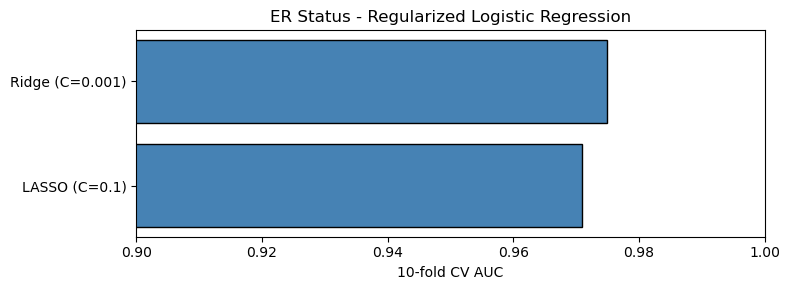


=== All Targets: Ridge vs LASSO (CV Performance) ===


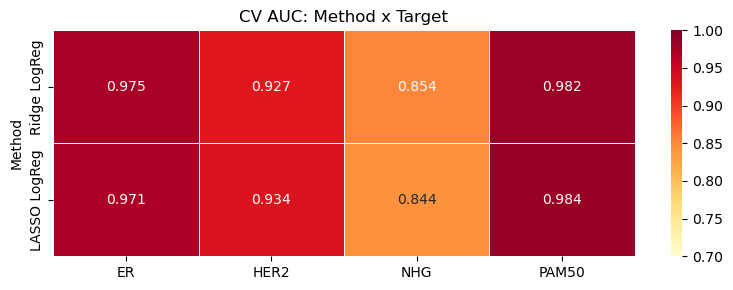

                  ER    HER2     NHG   PAM50
Ridge LogReg  0.9749  0.9274  0.8539  0.9822
LASSO LogReg  0.9710  0.9340  0.8437  0.9836


In [21]:
best_models = {
	"ER": Pipeline([
		("scaler", StandardScaler()),
		("lr", LogisticRegression(penalty="l1", C=best_C_lasso, solver="liblinear",
			max_iter=5000, random_state=42))
	]),
	"HER2": Pipeline([
		("scaler", StandardScaler()),
		("lr", LogisticRegression(penalty="l2", C=best_C_ridge, max_iter=5000,
			class_weight="balanced", random_state=42))
	]),
	"NHG": Pipeline([
		("scaler", StandardScaler()),
		("lr", LogisticRegression(penalty="l2", C=best_C_ridge,
			solver="lbfgs", max_iter=5000,
			class_weight="balanced", random_state=42))
	]),
	"PAM50": Pipeline([
		("scaler", StandardScaler()),
		("lr", LogisticRegression(penalty="l2", C=best_C_ridge,
			solver="lbfgs", max_iter=5000,
			class_weight="balanced", random_state=42))
	]),
}

fitted_models = {}
for target_name, pipe in best_models.items():
	ds = datasets[target_name]
	pipe.fit(ds["X_train"], ds["y_train"])
	fitted_models[target_name] = pipe
	print(f"{target_name}: model fitted on {ds['X_train'].shape[0]} training samples")

print("\n=== ER Status: Ridge vs LASSO (CV Performance) ===")
er_results = pd.DataFrame({
	"Method": [f"Ridge (C={best_C_ridge})", f"LASSO (C={best_C_lasso})"],
	"CV AUC": [max(ridge_aucs), max(lasso_aucs)]
}).sort_values("CV AUC", ascending=False)
print(er_results.to_string(index=False))

plt.figure(figsize=(8, 3))
plt.barh(er_results["Method"], er_results["CV AUC"], color="steelblue", edgecolor="black")
plt.xlabel("10-fold CV AUC")
plt.title("ER Status - Regularized Logistic Regression")
plt.xlim(0.9, 1.0)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n=== All Targets: Ridge vs LASSO (CV Performance) ===")
er_matched = {
	"Ridge LogReg": max(ridge_aucs),
	"LASSO LogReg": max(lasso_aucs),
}
all_results = pd.DataFrame({
	"ER": er_matched,
	"HER2": her2_results,
	"NHG": nhg_results,
	"PAM50": pam50_results,
})

plt.figure(figsize=(8, 3))
sns.heatmap(all_results, annot=True, fmt=".3f", cmap="YlOrRd", vmin=0.7, vmax=1.0,
	linewidths=0.5)
plt.title("CV AUC: Method x Target")
plt.ylabel("Method")
plt.tight_layout()
plt.show()

print(all_results.round(4))

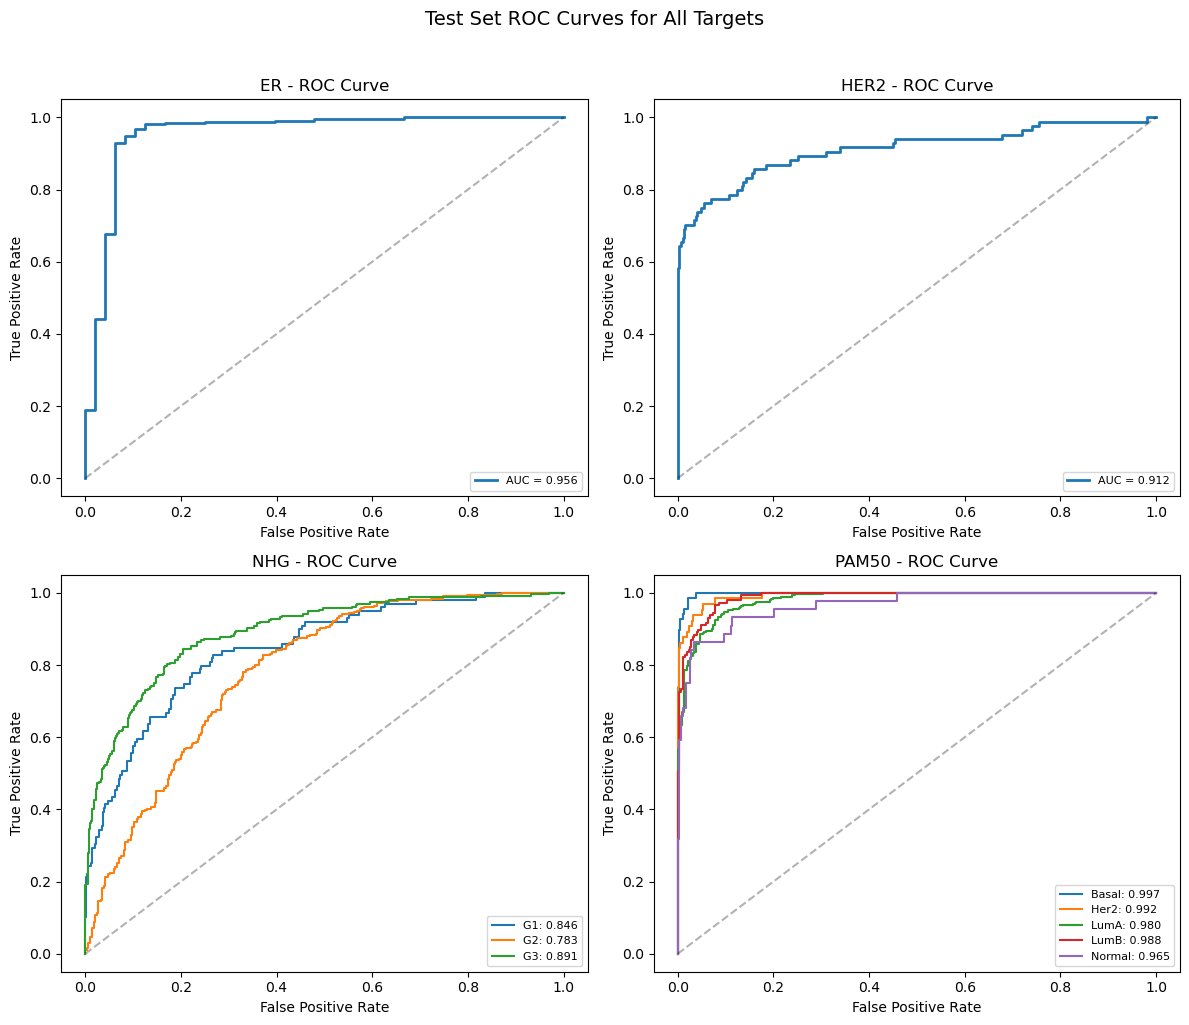

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, target_name in zip(axes.flat, ["ER", "HER2", "NHG", "PAM50"]):
	ds = datasets[target_name]
	pipe = fitted_models[target_name]
	y_test = ds["y_test"]

	if ds["type"] == "binary":
		y_prob = pipe.predict_proba(ds["X_test"])[:, 1]
		fpr, tpr, _ = roc_curve(y_test, y_prob)
		auc_val = roc_auc_score(y_test, y_prob)
		ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_val:.3f}")
		ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
	else:
		y_prob = pipe.predict_proba(ds["X_test"])
		classes = pipe.classes_
		for i, cls in enumerate(classes):
			y_binary = (y_test == cls).astype(int)
			fpr, tpr, _ = roc_curve(y_binary, y_prob[:, i])
			auc_val = roc_auc_score(y_binary, y_prob[:, i])
			ax.plot(fpr, tpr, linewidth=1.5, label=f"{cls}: {auc_val:.3f}")
		ax.plot([0, 1], [0, 1], "k--", alpha=0.3)

	ax.set_xlabel("False Positive Rate")
	ax.set_ylabel("True Positive Rate")
	ax.set_title(f"{target_name} - ROC Curve")
	ax.legend(loc="lower right", fontsize=8)

plt.suptitle("Test Set ROC Curves for All Targets", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("data/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

#### LASSO Regularization Path

The regularization path shows how LASSO performs feature selection as regularization strength varies.

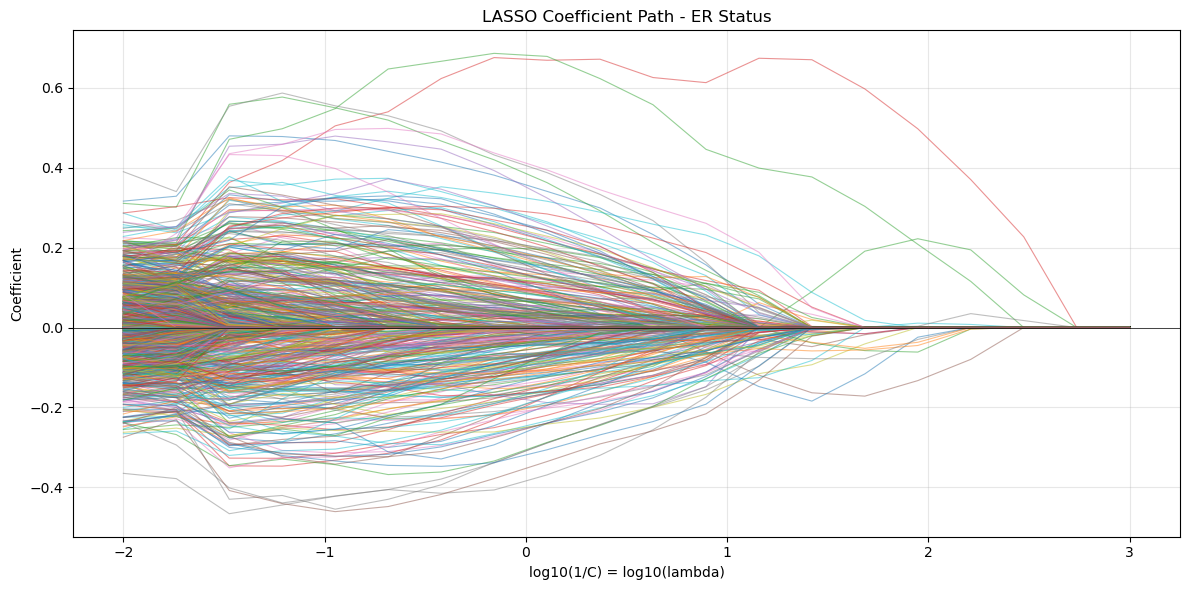

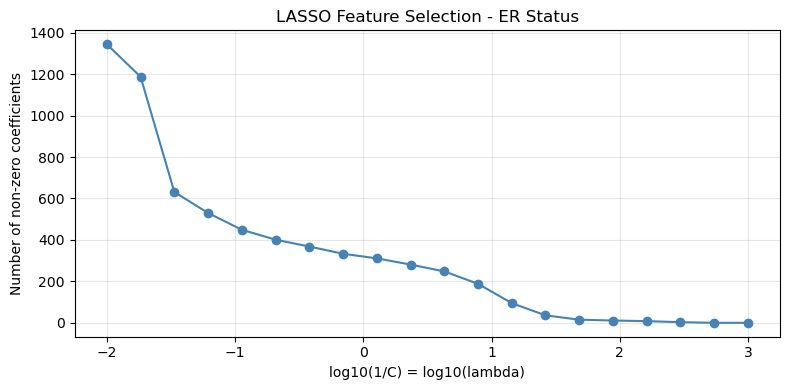

In [23]:
C_range = np.logspace(-3, 2, 20)
coef_paths = []

scaler_path = StandardScaler()
X_train_scaled = scaler_path.fit_transform(X_train_er)

for C in C_range:
	lr = LogisticRegression(penalty="l1", C=C, solver="liblinear",
		max_iter=5000, random_state=42)
	lr.fit(X_train_scaled, y_train_er)
	coef_paths.append(lr.coef_[0].copy())

coef_paths = np.array(coef_paths)

plt.figure(figsize=(12, 6))
ever_nonzero = np.any(coef_paths != 0, axis=0)
for j in np.where(ever_nonzero)[0]:
	plt.plot(np.log10(1.0 / C_range), coef_paths[:, j], alpha=0.5, linewidth=0.8)

plt.xlabel("log10(1/C) = log10(lambda)")
plt.ylabel("Coefficient")
plt.title("LASSO Coefficient Path - ER Status")
plt.axhline(0, color="black", linewidth=0.5)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

n_nonzero = np.sum(coef_paths != 0, axis=1)
plt.figure(figsize=(8, 4))
plt.plot(np.log10(1.0 / C_range), n_nonzero, "o-", color="steelblue")
plt.xlabel("log10(1/C) = log10(lambda)")
plt.ylabel("Number of non-zero coefficients")
plt.title("LASSO Feature Selection - ER Status")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Top Predictive Genes by Target

We extract and compare the genes selected by LASSO for each biomarker.

In [24]:
coef_df = None
for target_name in ["ER", "HER2"]:
	ds = datasets[target_name]
	scaler_tmp = StandardScaler()
	X_sc = scaler_tmp.fit_transform(ds["X_train"])
	lr = LogisticRegression(penalty="l1", C=best_C_lasso, solver="liblinear",
		max_iter=5000, random_state=42)
	lr.fit(X_sc, ds["y_train"])

	coefs = lr.coef_[0]
	df = pd.DataFrame({"Gene": gene_cols, "Coefficient": coefs})
	df = df[df["Coefficient"] != 0]
	df["Direction"] = np.where(df["Coefficient"] > 0, "Positive", "Negative")
	df["Abs_Coef"] = df["Coefficient"].abs()
	df = df.sort_values("Abs_Coef", ascending=False)
	
	if target_name == "ER":
		coef_df = df.copy()

	print(f"\n=== {target_name} - Top 15 LASSO Genes ===")
	print(f"Total non-zero: {len(df)}")
	print(df.head(15)[["Gene", "Coefficient", "Direction"]].to_string(index=False))


=== ER - Top 15 LASSO Genes ===
Total non-zero: 162
     Gene  Coefficient Direction
     ESR1     0.630376  Positive
 BC070495     0.415490  Positive
       XG     0.242770  Positive
    ZG16B     0.213512  Positive
LINC00839    -0.191639  Negative
    CRIP1     0.169419  Positive
      SP6    -0.165453  Negative
     CPA4    -0.149318  Negative
LINC01088    -0.142158  Negative
 FLJ22184    -0.138564  Negative
   IL17RE    -0.127495  Negative
   SLC4A8     0.125073  Positive
 SNORD14B    -0.123102  Negative
 RNU6-82P     0.122760  Positive
     MTL5     0.121988  Positive

=== HER2 - Top 15 LASSO Genes ===
Total non-zero: 269
    Gene  Coefficient Direction
   ERBB2     1.114977  Positive
   MIEN1     0.558705  Positive
    GRB7     0.558108  Positive
DQ571524    -0.234841  Negative
   GSDMA     0.213545  Positive
   BNIPL    -0.203330  Negative
 HTJA258     0.199958  Positive
SNORD58C     0.184352  Positive
  ZNF229    -0.184163  Negative
   TOP2A     0.166972  Positive
   BEND7    

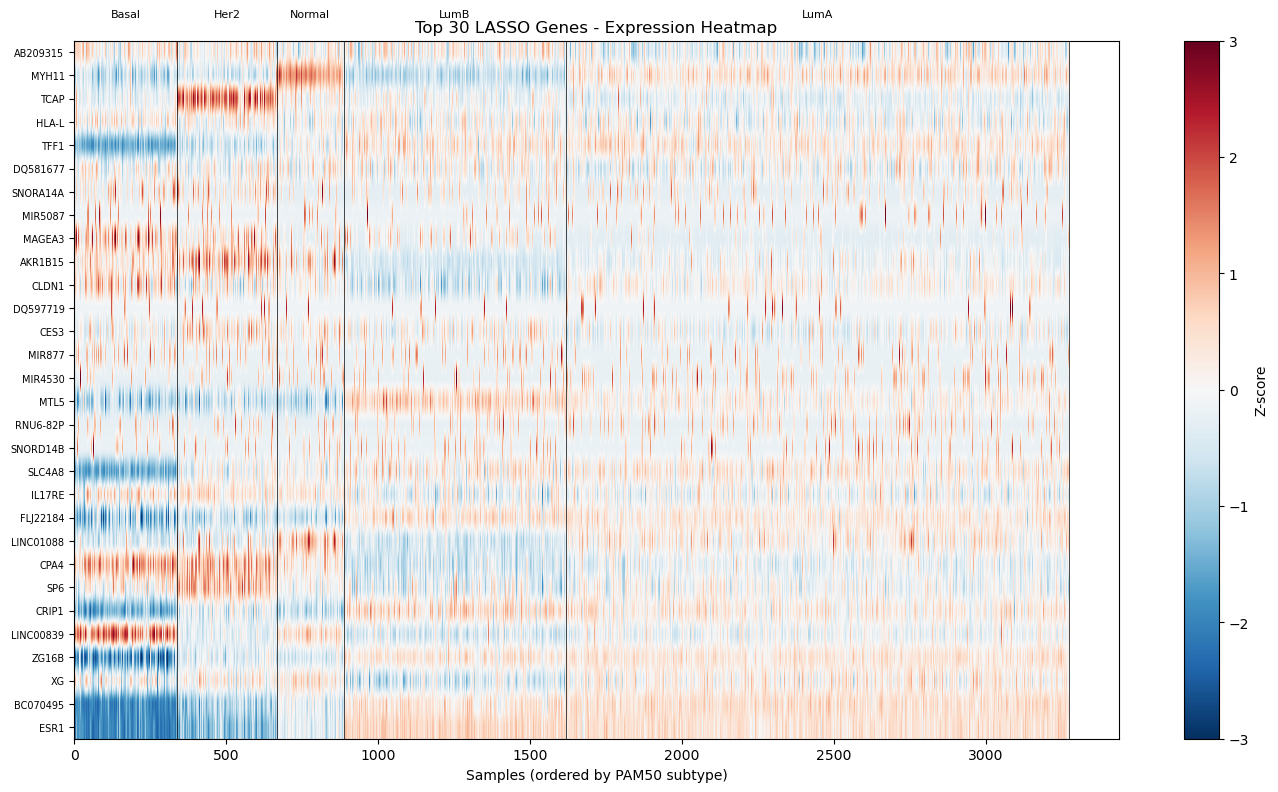

In [25]:
pipe_lasso_er = fitted_models["ER"]
coefs_er = pipe_lasso_er.named_steps["lr"].coef_[0]
top30_idx = np.argsort(np.abs(coefs_er))[-30:]
top30_genes = [gene_cols[i] for i in top30_idx]

heatmap_df = merged[top30_genes + ["pam50 subtype"]].copy()
subtype_order = ["Basal", "Her2", "Normal", "LumB", "LumA"]
heatmap_df["subtype_rank"] = heatmap_df["pam50 subtype"].map(
	{s: i for i, s in enumerate(subtype_order)}
)
heatmap_df = heatmap_df.sort_values("subtype_rank")

expr_heatmap = heatmap_df[top30_genes].values
expr_z = (expr_heatmap - expr_heatmap.mean(axis=0)) / expr_heatmap.std(axis=0)

plt.figure(figsize=(14, 8))
plt.imshow(expr_z.T, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3)
plt.yticks(range(len(top30_genes)), top30_genes, fontsize=7)
plt.xlabel("Samples (ordered by PAM50 subtype)")
plt.title("Top 30 LASSO Genes - Expression Heatmap")
plt.colorbar(label="Z-score")

cum = 0
for st in subtype_order:
	n = (heatmap_df["pam50 subtype"] == st).sum()
	plt.axvline(cum + n, color="black", linewidth=0.5)
	plt.text(cum + n / 2, -1.5, st, ha="center", fontsize=8, rotation=0)
	cum += n

plt.tight_layout()
plt.savefig("data/gene_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

---

### Method 2 Results: Differential Gene Expression

#### DEG Analysis: ER+ vs ER-

We perform t-tests for each gene and report significance after FDR correction.

In [26]:
X_tr_er = datasets["ER"]["X_train"]
y_tr_er = datasets["ER"]["y_train"]
gene_names = np.array(gene_cols)

X_pos = X_tr_er[y_tr_er == 1]  # ER+
X_neg = X_tr_er[y_tr_er == 0]  # ER-
print(f"ER+ samples: {X_pos.shape[0]}, ER- samples: {X_neg.shape[0]}")

t_stats = np.zeros(len(gene_cols))
p_vals = np.zeros(len(gene_cols))
for i in range(len(gene_cols)):
	t_stats[i], p_vals[i] = stats.ttest_ind(X_pos[:, i], X_neg[:, i], equal_var=False)

log2fc = X_pos.mean(axis=0) - X_neg.mean(axis=0)

reject, adj_pvals, _, _ = multipletests(p_vals, method="fdr_bh")

deg_results = pd.DataFrame({
	"Gene": gene_names,
	"log2FC": log2fc,
	"raw_pval": p_vals,
	"adj_pval": adj_pvals,
	"t_stat": t_stats,
}).sort_values("adj_pval")

n_sig = (deg_results["adj_pval"] < 0.05).sum()
n_sig_fc = ((deg_results["adj_pval"] < 0.05) & (deg_results["log2FC"].abs() > 1)).sum()
print(f"\nSignificant genes (adj_p < 0.05): {n_sig} / {len(gene_cols)}")
print(f"Significant AND |log2FC| > 1: {n_sig_fc}")
print(f"\nTop 20 DEGs by adjusted p-value:")
print(deg_results.head(20)[["Gene", "log2FC", "adj_pval"]].to_string(index=False))

ER+ samples: 2265, ER- samples: 193

Significant genes (adj_p < 0.05): 3531 / 5000
Significant AND |log2FC| > 1: 1273

Top 20 DEGs by adjusted p-value:
        Gene   log2FC      adj_pval
        CST9 2.890220 1.544085e-188
       CST9L 1.026655 4.008067e-176
    MAPT-IT1 1.687687 9.664027e-163
       TPRG1 3.185115 4.945108e-135
   TPRG1-AS2 3.033018 8.322812e-126
        NAT1 3.771869 1.313067e-120
     FAM196A 2.017965 2.683668e-120
       TPSG1 2.709235 8.026717e-116
     SLC39A6 2.408250 1.700560e-115
    MAPT-AS1 2.630552 1.080666e-114
       DCDC5 1.696302 3.716878e-112
      POTEKP 2.947318 4.934094e-112
  ELOVL2-AS1 1.204249 4.397180e-111
     TMPRSS6 2.842547 4.395043e-109
        ESR1 5.126724 3.677398e-107
   LINC01087 1.692611 4.523601e-105
   SERPINA11 4.100514 5.316957e-105
    BC070495 3.637369 3.499720e-104
LOC101054525 3.065738 1.523745e-103
        SYT9 3.076127 1.890194e-102


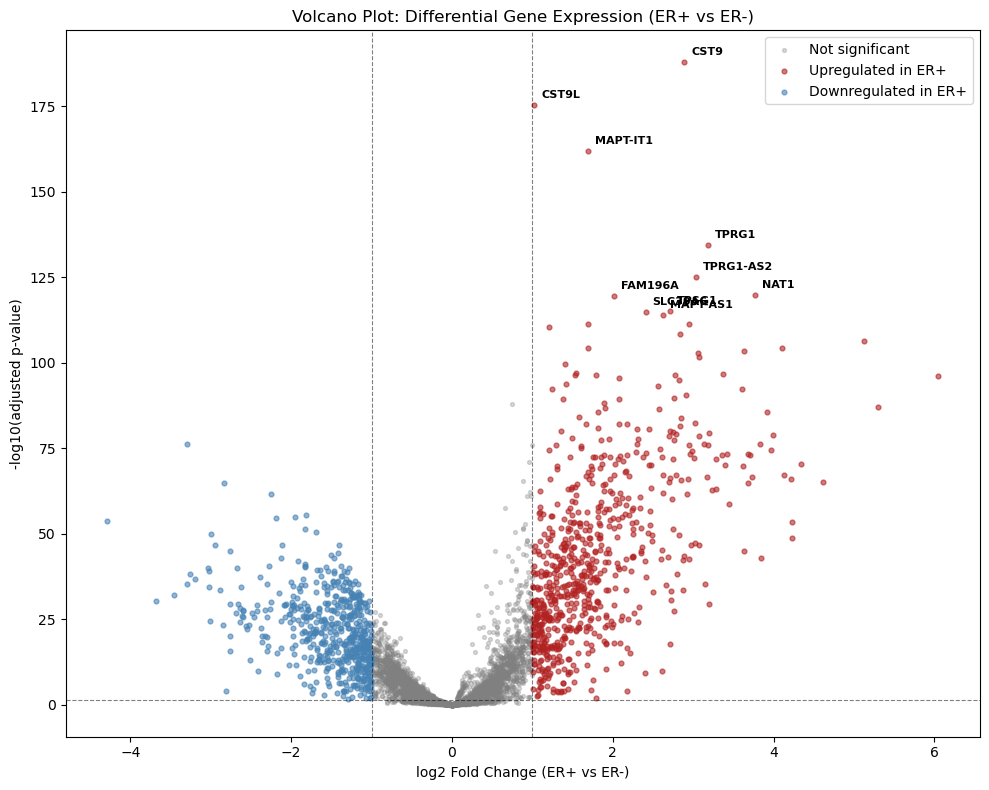

In [27]:
fig, ax = plt.subplots(figsize=(10, 8))

neg_log_p = -np.log10(deg_results["adj_pval"].clip(lower=1e-300))
fc = deg_results["log2FC"]

up = (fc > 1) & (deg_results["adj_pval"] < 0.05)
down = (fc < -1) & (deg_results["adj_pval"] < 0.05)
ns = ~(up | down)

ax.scatter(fc[ns], neg_log_p[ns], c="grey", alpha=0.3, s=8, label="Not significant")
ax.scatter(fc[up], neg_log_p[up], c="firebrick", alpha=0.6, s=12, label="Upregulated in ER+")
ax.scatter(fc[down], neg_log_p[down], c="steelblue", alpha=0.6, s=12, label="Downregulated in ER+")

ax.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.axvline(1, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.axvline(-1, color="black", linestyle="--", linewidth=0.8, alpha=0.5)

top10 = deg_results.head(10)
for _, row in top10.iterrows():
	ax.annotate(
		row["Gene"],
		xy=(row["log2FC"], -np.log10(max(row["adj_pval"], 1e-300))),
		fontsize=8, fontweight="bold",
		xytext=(5, 5), textcoords="offset points",
	)

ax.set_xlabel("log2 Fold Change (ER+ vs ER-)")
ax.set_ylabel("-log10(adjusted p-value)")
ax.set_title("Volcano Plot: Differential Gene Expression (ER+ vs ER-)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Method 2 Results: Differential Gene Expression

#### DEG-Based Gene Selection and Stability

We select genes passing both fold-change (|log2FC| > 1) and significance (adj. p < 0.05) thresholds, and assess stability through cross-validated DEG selection.

In [28]:
fc_thresh = 1.0
deg_mask_strict = (deg_results["adj_pval"] < 0.05) & (deg_results["log2FC"].abs() > fc_thresh)
deg_genes_strict = deg_results.loc[deg_mask_strict, "Gene"].values

if len(deg_genes_strict) < 20:
	fc_thresh = 0.5
	deg_mask_strict = (deg_results["adj_pval"] < 0.05) & (deg_results["log2FC"].abs() > fc_thresh)
	deg_genes_strict = deg_results.loc[deg_mask_strict, "Gene"].values
	print(f"Relaxed threshold to |log2FC| > {fc_thresh}")

print(f"DEGs selected (single-pass): {len(deg_genes_strict)} genes (|log2FC| > {fc_thresh}, adj_p < 0.05)")
print(f"\nTop 20 DEGs by significance:")
top_degs = deg_results.loc[deg_mask_strict].head(20)
print(top_degs[["Gene", "log2FC", "adj_pval"]].to_string(index=False))

deg_gene_set = set(deg_genes_strict)
deg_col_mask = np.array([g in deg_gene_set for g in gene_cols])
print(f"\nDEG feature mask: {deg_col_mask.sum()} / {len(gene_cols)} genes selected")

skf_deg = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_gene_sets = []

for fold_idx, (train_idx, _) in enumerate(skf_deg.split(X_tr_er, y_tr_er)):
	X_fold = X_tr_er[train_idx]
	y_fold = y_tr_er[train_idx]
	X_f_pos = X_fold[y_fold == 1]
	X_f_neg = X_fold[y_fold == 0]

	fold_pvals = np.array([
		stats.ttest_ind(X_f_pos[:, i], X_f_neg[:, i], equal_var=False)[1]
		for i in range(len(gene_cols))
	])
	fold_fc = X_f_pos.mean(axis=0) - X_f_neg.mean(axis=0)
	_, fold_adj, _, _ = multipletests(fold_pvals, method="fdr_bh")

	fold_selected = set(gene_names[(fold_adj < 0.05) & (np.abs(fold_fc) > fc_thresh)])
	fold_gene_sets.append(fold_selected)
	print(f"  Fold {fold_idx + 1}: {len(fold_selected)} DEGs")

stable_degs = fold_gene_sets[0]
for s in fold_gene_sets[1:]:
	stable_degs = stable_degs & s

print(f"\nStable DEGs (selected in all 5 folds): {len(stable_degs)}")
print(f"Single-pass DEGs: {len(deg_genes_strict)}")
print(f"Overlap: {len(stable_degs & deg_gene_set)} / {len(deg_genes_strict)} single-pass DEGs are stable")

stable_deg_mask = np.array([g in stable_degs for g in gene_cols])
print(f"\nUsing {stable_deg_mask.sum()} stable DEGs for advanced model comparison")

DEGs selected (single-pass): 1273 genes (|log2FC| > 1.0, adj_p < 0.05)

Top 20 DEGs by significance:
        Gene   log2FC      adj_pval
        CST9 2.890220 1.544085e-188
       CST9L 1.026655 4.008067e-176
    MAPT-IT1 1.687687 9.664027e-163
       TPRG1 3.185115 4.945108e-135
   TPRG1-AS2 3.033018 8.322812e-126
        NAT1 3.771869 1.313067e-120
     FAM196A 2.017965 2.683668e-120
       TPSG1 2.709235 8.026717e-116
     SLC39A6 2.408250 1.700560e-115
    MAPT-AS1 2.630552 1.080666e-114
       DCDC5 1.696302 3.716878e-112
      POTEKP 2.947318 4.934094e-112
  ELOVL2-AS1 1.204249 4.397180e-111
     TMPRSS6 2.842547 4.395043e-109
        ESR1 5.126724 3.677398e-107
   LINC01087 1.692611 4.523601e-105
   SERPINA11 4.100514 5.316957e-105
    BC070495 3.637369 3.499720e-104
LOC101054525 3.065738 1.523745e-103
        SYT9 3.076127 1.890194e-102

DEG feature mask: 1273 / 5000 genes selected
  Fold 1: 1238 DEGs
  Fold 2: 1312 DEGs
  Fold 3: 1291 DEGs
  Fold 4: 1277 DEGs
  Fold 5: 1262 DE

---

### Method 3 Results: HistGradientBoosting

#### Performance on Full vs DEG-Selected Features

We compare HGB performance using all ~5,000 genes vs only the stable DEG-selected genes.

In [29]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
advanced_er_results = {}

print("=== HistGradientBoosting (Full Features) ===")
pipe_hgb = Pipeline([
	("scaler", StandardScaler()),
	("hgb", HistGradientBoostingClassifier(random_state=42)),
])
param_grid_hgb = {
	"hgb__max_depth": [3, 5, 7],
	"hgb__learning_rate": [0.01, 0.1],
	"hgb__max_iter": [200],
}
gs_hgb = GridSearchCV(pipe_hgb, param_grid_hgb, cv=cv5, scoring="roc_auc", n_jobs=-1)
gs_hgb.fit(X_tr_er, y_tr_er)
print(f"Best params: {gs_hgb.best_params_}")
print(f"Best CV AUC: {gs_hgb.best_score_:.4f}")
advanced_er_results["HGB (Full)"] = gs_hgb.best_score_

X_tr_deg = X_tr_er[:, stable_deg_mask]
print(f"\n=== HistGradientBoosting (DEG Features: {X_tr_deg.shape[1]} genes) ===")
pipe_hgb_deg = Pipeline([
	("scaler", StandardScaler()),
	("hgb", HistGradientBoostingClassifier(random_state=42)),
])
gs_hgb_deg = GridSearchCV(pipe_hgb_deg, param_grid_hgb, cv=cv5, scoring="roc_auc", n_jobs=-1)
gs_hgb_deg.fit(X_tr_deg, y_tr_er)
print(f"Best params: {gs_hgb_deg.best_params_}")
print(f"Best CV AUC: {gs_hgb_deg.best_score_:.4f}")
advanced_er_results["HGB (DEG)"] = gs_hgb_deg.best_score_

advanced_er_results["Ridge LogReg"] = max(ridge_aucs)
advanced_er_results["LASSO LogReg"] = max(lasso_aucs)

adv_df = pd.DataFrame([
	{"Model": k, "CV AUC": v} for k, v in advanced_er_results.items()
]).sort_values("CV AUC", ascending=False)
print("\n=== ER Status: Linear vs Nonlinear Comparison ===")
print(adv_df.to_string(index=False))

=== HistGradientBoosting (Full Features) ===
Best params: {'hgb__learning_rate': 0.1, 'hgb__max_depth': 5, 'hgb__max_iter': 200}
Best CV AUC: 0.9750

=== HistGradientBoosting (DEG Features: 1123 genes) ===
Best params: {'hgb__learning_rate': 0.1, 'hgb__max_depth': 3, 'hgb__max_iter': 200}
Best CV AUC: 0.9742

=== ER Status: Linear vs Nonlinear Comparison ===
       Model   CV AUC
  HGB (Full) 0.974952
Ridge LogReg 0.974885
   HGB (DEG) 0.974181
LASSO LogReg 0.970970


In [30]:
print("=== HistGradientBoosting Across All Targets ===\n")
hgb_results = {}

for target_name in ["ER", "HER2", "NHG", "PAM50"]:
	ds = datasets[target_name]
	X_tr, y_tr = ds["X_train"], ds["y_train"]
	scoring = "roc_auc" if ds["type"] == "binary" else "roc_auc_ovr"

	pipe = Pipeline([
		("scaler", StandardScaler()),
		("hgb", HistGradientBoostingClassifier(random_state=42)),
	])
	gs = GridSearchCV(
		pipe,
		{"hgb__max_depth": [3, 5], "hgb__learning_rate": [0.1], "hgb__max_iter": [200]},
		cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
		scoring=scoring, n_jobs=-1,
	)
	gs.fit(X_tr, y_tr)
	hgb_results[target_name] = gs.best_score_
	print(f"{target_name}: CV AUC = {gs.best_score_:.4f} (best params: {gs.best_params_})")

print("\n=== Comparison: Best Linear vs HistGradientBoosting ===")
linear_best = {
	"ER": max(all_results["ER"]),
	"HER2": max(all_results["HER2"]),
	"NHG": max(all_results["NHG"]),
	"PAM50": max(all_results["PAM50"]),
}
comp_df = pd.DataFrame({
	"Target": list(hgb_results.keys()),
	"Best Linear": [linear_best[t] for t in hgb_results],
	"HGB": list(hgb_results.values()),
	"Difference": [hgb_results[t] - linear_best[t] for t in hgb_results],
})
print(comp_df.to_string(index=False))

=== HistGradientBoosting Across All Targets ===

ER: CV AUC = 0.9750 (best params: {'hgb__learning_rate': 0.1, 'hgb__max_depth': 5, 'hgb__max_iter': 200})
HER2: CV AUC = 0.9315 (best params: {'hgb__learning_rate': 0.1, 'hgb__max_depth': 5, 'hgb__max_iter': 200})
NHG: CV AUC = 0.8553 (best params: {'hgb__learning_rate': 0.1, 'hgb__max_depth': 5, 'hgb__max_iter': 200})
PAM50: CV AUC = 0.9877 (best params: {'hgb__learning_rate': 0.1, 'hgb__max_depth': 3, 'hgb__max_iter': 200})

=== Comparison: Best Linear vs HistGradientBoosting ===
Target  Best Linear      HGB  Difference
    ER     0.974885 0.974952    0.000067
  HER2     0.934048 0.931453   -0.002596
   NHG     0.853868 0.855251    0.001383
 PAM50     0.983606 0.987704    0.004098


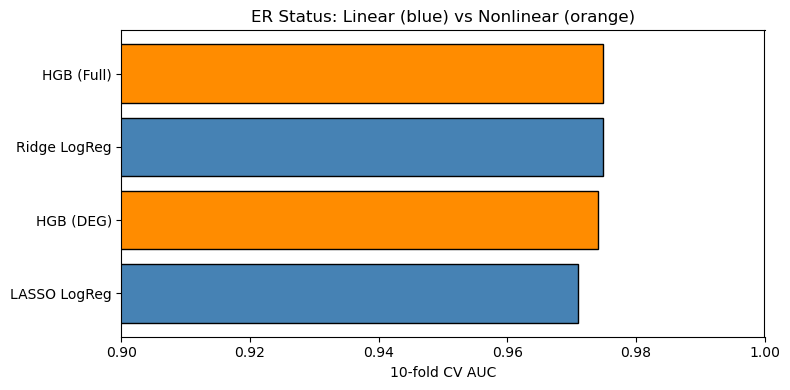

Best linear model (ER): 0.9749
Best nonlinear model (ER): 0.9750
Difference: +0.0001
       Model   CV AUC
  HGB (Full) 0.974952
Ridge LogReg 0.974885
   HGB (DEG) 0.974181
LASSO LogReg 0.970970


In [31]:
all_er_models = {
	"Ridge LogReg": max(ridge_aucs),
	"LASSO LogReg": max(lasso_aucs),
	"HGB (Full)": advanced_er_results["HGB (Full)"],
	"HGB (DEG)": advanced_er_results["HGB (DEG)"],
}

comp_all = pd.DataFrame([
	{"Model": k, "CV AUC": v} for k, v in all_er_models.items()
]).sort_values("CV AUC", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["darkorange" if "HGB" in m else "steelblue" for m in comp_all["Model"]]
ax.barh(comp_all["Model"], comp_all["CV AUC"], color=colors, edgecolor="black")
ax.set_xlabel("10-fold CV AUC")
ax.set_title("ER Status: Linear (blue) vs Nonlinear (orange)")
ax.set_xlim(0.9, 1.0)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

best_linear = max(max(ridge_aucs), max(lasso_aucs))
best_nonlinear = advanced_er_results["HGB (Full)"]
print(f"Best linear model (ER): {best_linear:.4f}")
print(f"Best nonlinear model (ER): {best_nonlinear:.4f}")
print(f"Difference: {best_nonlinear - best_linear:+.4f}")
print(comp_all.to_string(index=False))

## Conclusions

### What We Learned

We evaluated three approaches for predicting breast cancer biomarkers from RNA-seq data: differential gene expression testing, regularized linear regression (LASSO/Ridge), and nonlinear gradient boosting. All methods achieved strong predictive performance (ER AUC > 0.97, HER2 > 0.93, PAM50 > 0.98), largely confirming known biology. The main finding is that linear models suffice for this task—nonlinear gradient boosting did not improve upon LASSO/Ridge. Either the expression space is linearly separable, or the sample size is insufficient to learn complex interactions. We cannot distinguish between these explanations with the current dataset.

**Genes Identified:**
- **ER status:** ESR1 (estrogen receptor gene) is the strongest predictor (LASSO coef=0.63, log2FC=5.13), which is expected since ESR1 defines ER status biologically. More interesting: **BC070495** (lncRNA) appears in both top-15 LASSO and top-20 DEGs, suggesting convergent evidence. However, most other LASSO genes (XG, ZG16B, LINC00839, SP6, CPA4, IL17RE) are non-coding RNAs or poorly characterized, limiting biological insight. LASSO selected 162/5000 genes.
- **HER2 status:** ERBB2 (coefficient=1.11) and GRB7 (coefficient=0.56) confirm chr 17q12 amplification, the known mechanism. TOP2A (coefficient=0.17) contributes. 269 genes selected.
- **Top DEGs:** CST9/CST9L, TPRG1, NAT1, SERPINA11 beside ESR1. 1,273 genes significant (adj p<0.05), 1,123 stable across folds.

**Addressing the research questions:**
- **Q1 (individual associations):** ESR1 dominates (expected). NAT1, SERPINA11, cathepsins also significant. Many are uncharacterized.
- **Q2 (joint prediction):** LASSO needs 162 genes beyond ESR1 alone for optimal performance, suggesting ER status has complex expression correlates. Many are also LncRNA, which suggests that LASSO looks more strongly at correlation between genes. Correlation does not equal causation.
- **Q3 (nonlinear interactions):** No evidence—linear models matched gradient boosting. Either interactions don't exist or sample size insufficient to detect them.

### Limitations

Several limitations should temper the conclusions drawn from this work. First, we analyzed only the SCAN-B dataset (~3,200 samples after filtering). While this is a large cohort, it represents a single breast cancer study population, likely with shared technical and demographic biases. These results may not generalize to other sequencing protocols, patient populations (e.g., single-site vs. multi-site), or ethnic/geographic groups.

Second, our DEG analysis was limited to binary comparisons (ER+/- on ER status). For the three-class NHG predictions and five-class PAM50 predictions, we applied ANOVA-equivalent testing (LASSO) but did not perform univariate ANOVA with FDR correction on the multiclass targets, which could identify different gene sets for harder classification tasks.

Finally, gene expression alone may miss important biology. Tumor size, hormone receptor copy number (detected via qPCR or FISH in clinical practice), proliferation rate, and clinical stage might improve grade prediction and could interact non-additively with expression. Our variance-based feature filter may also exclude low-variance, high-impact genes (e.g., genes with rare mutations or context-dependent expression).

### New Questions

This work raises several new questions for future investigation:

1. **What is the functional role of BC070495?** This lncRNA showed convergent evidence from both LASSO and DEG analyses, but its biological mechanism in ER+ breast cancer is unknown. Does it regulate estrogen signaling, or is it merely a correlated bystander?

2. **Why does LASSO select so many poorly characterized genes?** Many top predictors (XG, ZG16B, LINC00839, SP6) lack functional annotation. Are these biologically meaningful, or artifacts of technical correlation? This points to gaps in the functional genomics literature for breast cancer.

3. **Could nonlinear interactions exist but require larger sample sizes?** We found no evidence for nonlinearity with ~3,200 samples. Would 10x or 100x more samples reveal gene-gene interactions, or is the expression space truly linearly separable for these biomarkers?

4. **Do LASSO gene signatures generalize across sequencing platforms?** Our models were trained on SCAN-B RNA-seq data. Would the same 162-gene ER signature perform well on microarray data, NanoString, or qPCR panels used in clinical settings?

### Future Steps

External validation on TCGA, METABRIC, and prospective cohorts is essential before claiming robust biomarker models.

Biologically, BC070495 is a priority follow-up candidate because it appears in both top LASSO and top DEG results; functional studies are needed to determine whether it is a driver or a correlated passenger.

Clinically, integrating expression with tumor size, stage, and additional assays may improve generalization and translational relevance across populations and sequencing platforms.

Despite these limitations, the convergence across methods, overlap with known breast cancer biology, and strong test set performance suggest the identified genes capture real predictive signal that could support future biomarker development with independent validation.

**Danny & Daniel:** Conclusion

## References

1. Brueffer et al. (2018). Clinical Value of RNA Sequencing-Based Classifiers for Prediction of the Five Conventional Breast Cancer Biomarkers. *JNCI*.
2. Parker et al. (2009). Supervised Risk Predictor of Breast Cancer Based on Intrinsic Subtypes. *JCO*.
3. Hastie, Tibshirani, Friedman. *The Elements of Statistical Learning*. Springer.
4. James et al. *An Introduction to Statistical Learning*. Springer.